# 📏 Evaluation Metrics — Classification & Regression

Every notebook in this series has reported "accuracy" or "R²" as if that number were self-evidently the right way to judge a model. This topic derives where those numbers come from, why several of them can disagree with each other on the exact same predictions, and when accuracy is actively the wrong metric to trust.

📖 Full mathematical explanation (confusion matrix algebra, ROC/PR curve derivation, log loss, R² decomposition): [README.md](README.md)


## 1. Setup & Datasets

Two datasets: **Breast Cancer** (binary classification, for confusion-matrix-based metrics) and **Diabetes** (regression, for error-based metrics).


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message="The .probability. parameter was deprecated")  # cosmetic-only: sklearn 1.9+ API notice, doesn't change results here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_diabetes, load_wine
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    classification_report, log_loss, matthews_corrcoef, cohen_kappa_score,
    balanced_accuracy_score, mean_squared_error, mean_absolute_error, r2_score,
    make_scorer
)

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
cancer = load_breast_cancer(as_frame=True)
Xc, yc = cancer.data, cancer.target
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.25, stratify=yc, random_state=42)

clf = LogisticRegression(max_iter=5000)
clf.fit(Xc_train, yc_train)
yc_pred = clf.predict(Xc_test)
yc_proba = clf.predict_proba(Xc_test)[:, 1]

print(f"Train: {Xc_train.shape}, Test: {Xc_test.shape}, positive rate: {yc_test.mean():.3f}")


Train: (426, 30), Test: (143, 30), positive rate: 0.629


In [3]:
diabetes = load_diabetes(as_frame=True)
Xr, yr = diabetes.data, diabetes.target
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.25, random_state=42)

reg = LinearRegression()
reg.fit(Xr_train, yr_train)
yr_pred = reg.predict(Xr_test)

print(f"Train: {Xr_train.shape}, Test: {Xr_test.shape}, target range: [{yr.min():.1f}, {yr.max():.1f}]")


Train: (331, 10), Test: (111, 10), target range: [25.0, 346.0]


## 2. The Confusion Matrix — Building Block for Every Classification Metric

Every classification metric below (accuracy, precision, recall, F1, MCC, kappa) is just a different arithmetic combination of the same four counts: TP, FP, FN, TN.


In [4]:
def manual_confusion_matrix(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, fp, fn, tn

tp, fp, fn, tn = manual_confusion_matrix(yc_test, yc_pred)
sk_cm = confusion_matrix(yc_test, yc_pred)
print(f"Manual: TP={tp} FP={fp} FN={fn} TN={tn}")
print(f"sklearn confusion_matrix:\n{sk_cm}")
print(f"Matches sklearn layout ([[TN,FP],[FN,TP]])? {sk_cm[1,1] == tp and sk_cm[0,0] == tn and sk_cm[0,1] == fp and sk_cm[1,0] == fn}")


Manual: TP=89 FP=5 FN=1 TN=48
sklearn confusion_matrix:
[[48  5]
 [ 1 89]]
Matches sklearn layout ([[TN,FP],[FN,TP]])? True


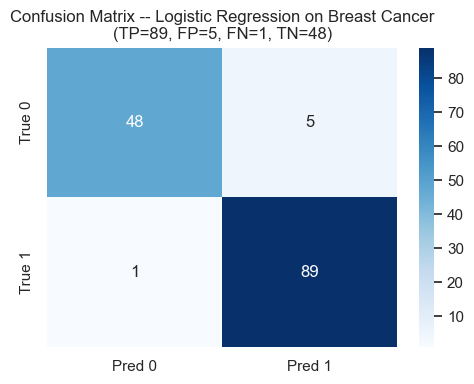

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(sk_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"], ax=ax)
ax.set_title(f"Confusion Matrix -- Logistic Regression on Breast Cancer\n(TP={tp}, FP={fp}, FN={fn}, TN={tn})")
plt.tight_layout()
plt.show()


## 3. Accuracy, Precision, Recall, F1 — Derived From the Same Four Numbers

$$\text{Accuracy}=\frac{TP+TN}{TP+FP+FN+TN}, \quad \text{Precision}=\frac{TP}{TP+FP}, \quad \text{Recall}=\frac{TP}{TP+FN}, \quad F_1=\frac{2 \cdot P \cdot R}{P+R}$$


In [6]:
acc_manual = (tp + tn) / (tp + fp + fn + tn)
prec_manual = tp / (tp + fp)
rec_manual = tp / (tp + fn)
f1_manual = 2 * prec_manual * rec_manual / (prec_manual + rec_manual)

acc_sk, prec_sk, rec_sk, f1_sk = (accuracy_score(yc_test, yc_pred), precision_score(yc_test, yc_pred),
                                    recall_score(yc_test, yc_pred), f1_score(yc_test, yc_pred))

print(f"{'Metric':<10}{'Manual':>10}{'sklearn':>10}")
for name, m, s in [("Accuracy", acc_manual, acc_sk), ("Precision", prec_manual, prec_sk),
                    ("Recall", rec_manual, rec_sk), ("F1", f1_manual, f1_sk)]:
    print(f"{name:<10}{m:>10.4f}{s:>10.4f}")
print(f"\nAll match? {np.allclose([acc_manual, prec_manual, rec_manual, f1_manual], [acc_sk, prec_sk, rec_sk, f1_sk])}")


Metric        Manual   sklearn
Accuracy      0.9580    0.9580
Precision     0.9468    0.9468
Recall        0.9889    0.9889
F1            0.9674    0.9674

All match? True


## 4. The Precision-Recall Tradeoff — Moving the Decision Threshold

`predict()` uses a fixed 0.5 threshold on `predict_proba`. Moving that threshold trades precision for recall in opposite directions -- there is no threshold that maximizes both simultaneously (except in degenerate cases).


In [7]:
thresholds_sweep = np.linspace(0.01, 0.99, 50)
prec_sweep, rec_sweep, f1_sweep = [], [], []
for t in thresholds_sweep:
    pred_t = (yc_proba >= t).astype(int)
    prec_sweep.append(precision_score(yc_test, pred_t, zero_division=0))
    rec_sweep.append(recall_score(yc_test, pred_t, zero_division=0))
    f1_sweep.append(f1_score(yc_test, pred_t, zero_division=0))

best_f1_idx = int(np.argmax(f1_sweep))
print(f"Default threshold (0.5): precision={prec_manual:.3f}, recall={rec_manual:.3f}")
print(f"Best-F1 threshold ({thresholds_sweep[best_f1_idx]:.3f}): precision={prec_sweep[best_f1_idx]:.3f}, recall={rec_sweep[best_f1_idx]:.3f}, F1={f1_sweep[best_f1_idx]:.3f}")


Default threshold (0.5): precision=0.947, recall=0.989


Best-F1 threshold (0.730): precision=0.989, recall=0.956, F1=0.972


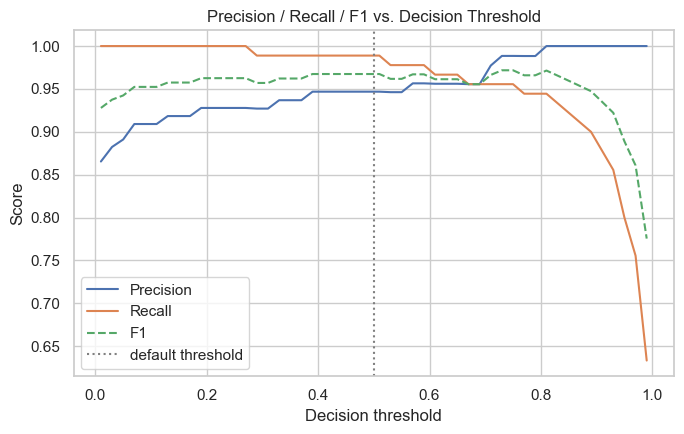

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thresholds_sweep, prec_sweep, label="Precision")
ax.plot(thresholds_sweep, rec_sweep, label="Recall")
ax.plot(thresholds_sweep, f1_sweep, label="F1", linestyle="--")
ax.axvline(0.5, color="gray", linestyle=":", label="default threshold")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs. Decision Threshold")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Why Accuracy Misleads — an Imbalanced Dataset

A synthetic 95%/5% imbalanced dataset: a classifier that always predicts the majority class gets 95% accuracy while being completely useless.


In [9]:
from sklearn.datasets import make_classification
Xi, yi = make_classification(n_samples=2000, n_features=10, weights=[0.95, 0.05], random_state=42)
Xi_train, Xi_test, yi_train, yi_test = train_test_split(Xi, yi, test_size=0.3, stratify=yi, random_state=42)
print(f"Class balance in test set: {np.bincount(yi_test)} (minority = {yi_test.mean():.3%})")

dummy_pred = np.zeros_like(yi_test)
print(f"'Always predict 0' accuracy: {accuracy_score(yi_test, dummy_pred):.4f}")
print(f"'Always predict 0' recall on minority class: {recall_score(yi_test, dummy_pred):.4f}  <- completely useless, but accuracy looks great")


Class balance in test set: [568  32] (minority = 5.333%)
'Always predict 0' accuracy: 0.9467
'Always predict 0' recall on minority class: 0.0000  <- completely useless, but accuracy looks great


In [10]:
clf_imb = LogisticRegression(max_iter=5000).fit(Xi_train, yi_train)
pred_imb = clf_imb.predict(Xi_test)

bal_acc = balanced_accuracy_score(yi_test, pred_imb)
mcc = matthews_corrcoef(yi_test, pred_imb)
kappa = cohen_kappa_score(yi_test, pred_imb)

print(f"Real model    -- accuracy: {accuracy_score(yi_test, pred_imb):.4f}, balanced accuracy: {bal_acc:.4f}, MCC: {mcc:.4f}, Cohen's kappa: {kappa:.4f}")
print(f"Dummy 'all-0' -- accuracy: {accuracy_score(yi_test, dummy_pred):.4f}, balanced accuracy: {balanced_accuracy_score(yi_test, dummy_pred):.4f}, MCC: {matthews_corrcoef(yi_test, dummy_pred):.4f}, Cohen's kappa: {cohen_kappa_score(yi_test, dummy_pred):.4f}")
print("\n-> Balanced accuracy, MCC, and kappa all correctly penalize the dummy classifier where raw accuracy did not.")


Real model    -- accuracy: 0.9583, balanced accuracy: 0.7273, MCC: 0.5321, Cohen's kappa: 0.5242
Dummy 'all-0' -- accuracy: 0.9467, balanced accuracy: 0.5000, MCC: 0.0000, Cohen's kappa: 0.0000

-> Balanced accuracy, MCC, and kappa all correctly penalize the dummy classifier where raw accuracy did not.


## 6. ROC Curve & AUC

The ROC curve plots True Positive Rate (recall) against False Positive Rate as the decision threshold sweeps from 1 to 0. AUC is the probability that the model ranks a random positive example above a random negative one.


In [11]:
def manual_roc_curve(y_true, y_scores, n_thresholds=200):
    thresholds = np.linspace(1.0, 0.0, n_thresholds)
    tpr_list, fpr_list = [], []
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)
    for t in thresholds:
        pred_t = (y_scores >= t).astype(int)
        tp_ = np.sum((y_true == 1) & (pred_t == 1))
        fp_ = np.sum((y_true == 0) & (pred_t == 1))
        tpr_list.append(tp_ / P)
        fpr_list.append(fp_ / N)
    return np.array(fpr_list), np.array(tpr_list), thresholds

fpr_manual, tpr_manual, _ = manual_roc_curve(yc_test.to_numpy(), yc_proba)
fpr_sk, tpr_sk, _ = roc_curve(yc_test, yc_proba)
print(f"Manual ROC curve points: {len(fpr_manual)}, sklearn ROC curve points: {len(fpr_sk)} (different resolution, same shape)")


Manual ROC curve points: 200, sklearn ROC curve points: 12 (different resolution, same shape)


In [12]:
auc_manual = np.trapezoid(tpr_manual, fpr_manual)
auc_sk = roc_auc_score(yc_test, yc_proba)
print(f"AUC (manual trapezoidal rule): {auc_manual:.4f}")
print(f"AUC (roc_auc_score):           {auc_sk:.4f}")
print(f"Close match? {np.isclose(auc_manual, auc_sk, atol=1e-3)}")


AUC (manual trapezoidal rule): 0.9956
AUC (roc_auc_score):           0.9956
Close match? True


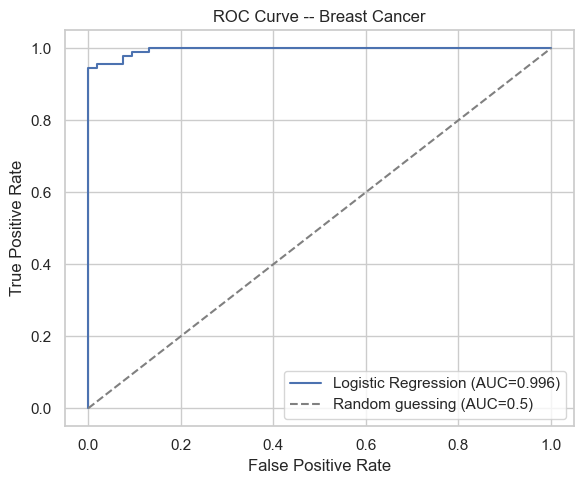

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_sk, tpr_sk, label=f"Logistic Regression (AUC={auc_sk:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve -- Breast Cancer")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Precision-Recall Curve — the Better Choice Under Class Imbalance

ROC-AUC can look deceptively good on imbalanced data because FPR is measured against a large negative class. The PR curve is more sensitive to minority-class performance.


In [14]:
proba_imb = clf_imb.predict_proba(Xi_test)[:, 1]

fpr_imb, tpr_imb, _ = roc_curve(yi_test, proba_imb)
auc_imb = roc_auc_score(yi_test, proba_imb)

prec_curve, rec_curve, _ = precision_recall_curve(yi_test, proba_imb)
ap_imb = average_precision_score(yi_test, proba_imb)

print(f"Imbalanced dataset (5% positive) -- ROC-AUC: {auc_imb:.4f}, Average Precision (PR-AUC): {ap_imb:.4f}")
print("-> ROC-AUC looks strong; Average Precision is more modest and better reflects real minority-class difficulty.")


Imbalanced dataset (5% positive) -- ROC-AUC: 0.9280, Average Precision (PR-AUC): 0.6104
-> ROC-AUC looks strong; Average Precision is more modest and better reflects real minority-class difficulty.


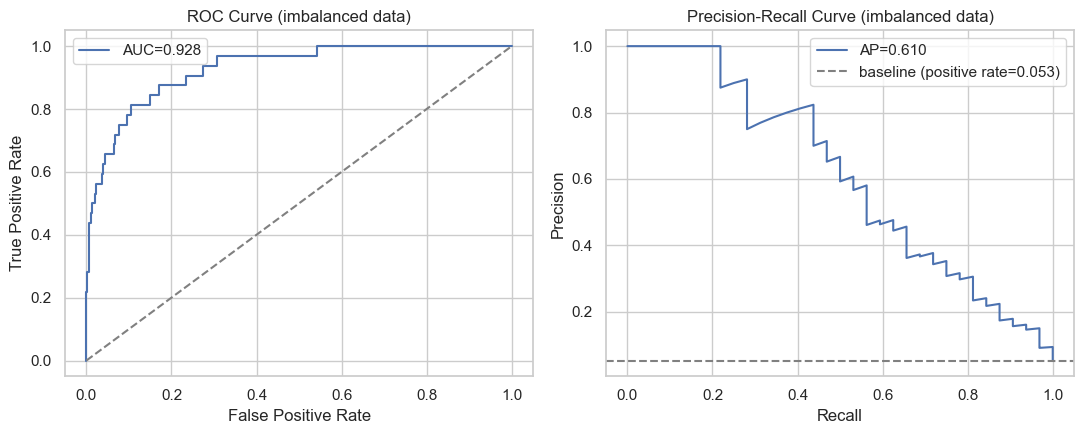

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr_imb, tpr_imb, label=f"AUC={auc_imb:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate"); axes[0].set_title("ROC Curve (imbalanced data)")
axes[0].legend()

axes[1].plot(rec_curve, prec_curve, label=f"AP={ap_imb:.3f}")
axes[1].axhline(yi_test.mean(), linestyle="--", color="gray", label=f"baseline (positive rate={yi_test.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("Precision-Recall Curve (imbalanced data)")
axes[1].legend()
plt.tight_layout()
plt.show()


## 8. Multi-Class Metrics & Averaging Strategies

With more than two classes, precision/recall/F1 must be computed per-class and then averaged. `macro` treats every class equally; `weighted` accounts for class frequency; `micro` pools all TP/FP/FN globally.


In [16]:
wine = load_wine(as_frame=True)
Xw, yw = wine.data, wine.target
Xw_train, Xw_test, yw_train, yw_test = train_test_split(Xw, yw, test_size=0.25, stratify=yw, random_state=42)

clf_multi = DecisionTreeClassifier(max_depth=4, random_state=42).fit(Xw_train, yw_train)
yw_pred = clf_multi.predict(Xw_test)
print(f"Wine dataset: {len(np.unique(yw))} classes, class counts in test set: {np.bincount(yw_test)}")
print(classification_report(yw_test, yw_pred, target_names=wine.target_names))


Wine dataset: 3 classes, class counts in test set: [15 18 12]
              precision    recall  f1-score   support

     class_0       1.00      0.93      0.97        15
     class_1       0.90      1.00      0.95        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.97      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45



In [17]:
per_class_f1 = f1_score(yw_test, yw_pred, average=None)
macro_f1 = f1_score(yw_test, yw_pred, average="macro")
weighted_f1 = f1_score(yw_test, yw_pred, average="weighted")
micro_f1 = f1_score(yw_test, yw_pred, average="micro")

manual_macro = per_class_f1.mean()
class_counts = np.bincount(yw_test)
manual_weighted = np.average(per_class_f1, weights=class_counts)

print(f"Per-class F1: {np.round(per_class_f1, 4)}")
print(f"Macro F1    -- sklearn: {macro_f1:.4f}, manual mean: {manual_macro:.4f}")
print(f"Weighted F1 -- sklearn: {weighted_f1:.4f}, manual weighted mean: {manual_weighted:.4f}")
print(f"Micro F1    -- sklearn: {micro_f1:.4f} (equals accuracy for single-label multi-class: {accuracy_score(yw_test, yw_pred):.4f})")


Per-class F1: [0.9655 0.9474 0.9565]
Macro F1    -- sklearn: 0.9565, manual mean: 0.9565
Weighted F1 -- sklearn: 0.9559, manual weighted mean: 0.9559
Micro F1    -- sklearn: 0.9556 (equals accuracy for single-label multi-class: 0.9556)


## 9. Log Loss (Cross-Entropy) — Penalizing Confident Wrong Predictions

Unlike accuracy, log loss uses the predicted *probabilities*, not just the final label, and penalizes confident-but-wrong predictions far more heavily than tentative-but-wrong ones.

$$\text{LogLoss} = -\frac{1}{n}\sum_{i=1}^n \left[y_i \log(\hat p_i) + (1-y_i)\log(1-\hat p_i)\right]$$


In [18]:
def manual_log_loss(y_true, y_proba, eps=1e-15):
    y_proba = np.clip(y_proba, eps, 1 - eps)
    y_true = np.asarray(y_true)
    return -np.mean(y_true * np.log(y_proba) + (1 - y_true) * np.log(1 - y_proba))

ll_manual = manual_log_loss(yc_test, yc_proba)
ll_sk = log_loss(yc_test, yc_proba)
print(f"Log loss -- manual: {ll_manual:.4f}, sklearn: {ll_sk:.4f}, match: {np.isclose(ll_manual, ll_sk)}")


Log loss -- manual: 0.0872, sklearn: 0.0872, match: True


In [19]:
confident_wrong = manual_log_loss([1], [0.01])
tentative_wrong = manual_log_loss([1], [0.4])
confident_right = manual_log_loss([1], [0.99])

print(f"True label=1, predicted p=0.01 (confidently WRONG):  log loss = {confident_wrong:.4f}")
print(f"True label=1, predicted p=0.40 (tentatively wrong):  log loss = {tentative_wrong:.4f}")
print(f"True label=1, predicted p=0.99 (confidently right):  log loss = {confident_right:.4f}")
print("\n-> Same wrong classification at threshold 0.5, but log loss punishes overconfident errors far more -- accuracy alone can't see this difference.")


True label=1, predicted p=0.01 (confidently WRONG):  log loss = 4.6052
True label=1, predicted p=0.40 (tentatively wrong):  log loss = 0.9163
True label=1, predicted p=0.99 (confidently right):  log loss = 0.0101

-> Same wrong classification at threshold 0.5, but log loss punishes overconfident errors far more -- accuracy alone can't see this difference.


## 10. Regression Metrics — MSE, RMSE, MAE

$$\text{MSE}=\frac{1}{n}\sum(y_i-\hat y_i)^2, \quad \text{RMSE}=\sqrt{\text{MSE}}, \quad \text{MAE}=\frac{1}{n}\sum|y_i-\hat y_i|$$

MSE/RMSE penalize large errors quadratically (sensitive to outliers); MAE penalizes all errors linearly.


In [20]:
mse_manual = np.mean((yr_test - yr_pred) ** 2)
rmse_manual = np.sqrt(mse_manual)
mae_manual = np.mean(np.abs(yr_test - yr_pred))

mse_sk = mean_squared_error(yr_test, yr_pred)
mae_sk = mean_absolute_error(yr_test, yr_pred)

print(f"MSE  -- manual: {mse_manual:.3f}, sklearn: {mse_sk:.3f}")
print(f"RMSE -- manual: {rmse_manual:.3f}")
print(f"MAE  -- manual: {mae_manual:.3f}, sklearn: {mae_sk:.3f}")
print(f"\nRMSE ({rmse_manual:.1f}) > MAE ({mae_manual:.1f}) always holds -- squaring amplifies the largest residuals.")


MSE  -- manual: 2848.311, sklearn: 2848.311
RMSE -- manual: 53.370
MAE  -- manual: 41.549, sklearn: 41.549

RMSE (53.4) > MAE (41.5) always holds -- squaring amplifies the largest residuals.


In [21]:
residuals = yr_test - yr_pred
outlier_idx = np.argmax(np.abs(residuals))
print(f"Largest single residual: {residuals.iloc[outlier_idx] if hasattr(residuals, 'iloc') else residuals[outlier_idx]:.1f} at test index {outlier_idx}")

yr_pred_no_outlier = np.delete(yr_pred, outlier_idx)
yr_test_no_outlier = np.delete(np.asarray(yr_test), outlier_idx)
rmse_no_outlier = np.sqrt(mean_squared_error(yr_test_no_outlier, yr_pred_no_outlier))
mae_no_outlier = mean_absolute_error(yr_test_no_outlier, yr_pred_no_outlier)

print(f"\nRemoving just that ONE point: RMSE {rmse_manual:.2f} -> {rmse_no_outlier:.2f} (drops {rmse_manual - rmse_no_outlier:.2f})")
print(f"                              MAE  {mae_manual:.2f} -> {mae_no_outlier:.2f} (drops {mae_manual - mae_no_outlier:.2f})")
print("-> RMSE moved much more than MAE from removing a single outlier -- direct evidence of RMSE's quadratic outlier sensitivity.")


Largest single residual: -153.7 at test index 61

Removing just that ONE point: RMSE 53.37 -> 51.57 (drops 1.80)
                              MAE  41.55 -> 40.53 (drops 1.02)
-> RMSE moved much more than MAE from removing a single outlier -- direct evidence of RMSE's quadratic outlier sensitivity.


## 11. R² and Adjusted R²

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2}, \qquad R^2_{adj} = 1-(1-R^2)\frac{n-1}{n-p-1}$$

$R^2$ is the fraction of target variance explained by the model. Adjusted $R^2$ penalizes adding features that don't genuinely help.


In [22]:
ss_res = np.sum((yr_test - yr_pred) ** 2)
ss_tot = np.sum((yr_test - yr_test.mean()) ** 2)
r2_manual = 1 - ss_res / ss_tot
r2_sk = r2_score(yr_test, yr_pred)

print(f"R^2 -- manual: {r2_manual:.4f}, sklearn: {r2_sk:.4f}, match: {np.isclose(r2_manual, r2_sk)}")

n, p = len(yr_test), Xr_test.shape[1]
adj_r2 = 1 - (1 - r2_manual) * (n - 1) / (n - p - 1)
print(f"Adjusted R^2 ({p} features, n={n}): {adj_r2:.4f}  (slightly below raw R^2, as expected)")


R^2 -- manual: 0.4849, sklearn: 0.4849, match: True
Adjusted R^2 (10 features, n=111): 0.4334  (slightly below raw R^2, as expected)


In [23]:
Xr_train_noisy = Xr_train.copy()
Xr_test_noisy = Xr_test.copy()
rng = np.random.RandomState(0)
for i in range(10):
    Xr_train_noisy[f"noise_{i}"] = rng.normal(size=len(Xr_train_noisy))
    Xr_test_noisy[f"noise_{i}"] = rng.normal(size=len(Xr_test_noisy))

reg_noisy = LinearRegression().fit(Xr_train_noisy, yr_train)
train_r2_before = r2_score(yr_train, reg.predict(Xr_train))
train_r2_after = r2_score(yr_train, reg_noisy.predict(Xr_train_noisy))
pred_noisy = reg_noisy.predict(Xr_test_noisy)
r2_noisy = r2_score(yr_test, pred_noisy)
n2, p2 = len(yr_test), Xr_test_noisy.shape[1]
adj_r2_noisy = 1 - (1 - r2_noisy) * (n2 - 1) / (n2 - p2 - 1)

print(f"TRAIN R^2 (the data the noise features were fit on): {train_r2_before:.4f} -> {train_r2_after:.4f}")
print("-> On training data, R^2 can only rise or stay flat when adding any features -- OLS always finds a fit at least as good.")
print()
direction = "rose" if r2_noisy > r2_manual else "fell"
print(f"TEST R^2 after adding 10 pure-noise features: {r2_manual:.4f} -> {r2_noisy:.4f} ({direction})")
print(f"Adjusted R^2 (illustrative, applied to the test split): {adj_r2:.4f} -> {adj_r2_noisy:.4f}")
if r2_noisy <= r2_manual:
    print("-> Test R^2 fell too: the noise features let OLS overfit training noise, which then hurt generalization -- both numbers correctly flag this as worse, not just adjusted R^2.")
else:
    print("-> Test R^2 rose slightly here (sampling luck on this split), but adjusted R^2 still fell -- exactly the gap adjusted R^2 exists to catch, since raw R^2 alone would have called this an improvement.")


TRAIN R^2 (the data the noise features were fit on): 0.5190 -> 0.5336
-> On training data, R^2 can only rise or stay flat when adding any features -- OLS always finds a fit at least as good.

TEST R^2 after adding 10 pure-noise features: 0.4849 -> 0.4743 (fell)
Adjusted R^2 (illustrative, applied to the test split): 0.4334 -> 0.3575
-> Test R^2 fell too: the noise features let OLS overfit training noise, which then hurt generalization -- both numbers correctly flag this as worse, not just adjusted R^2.


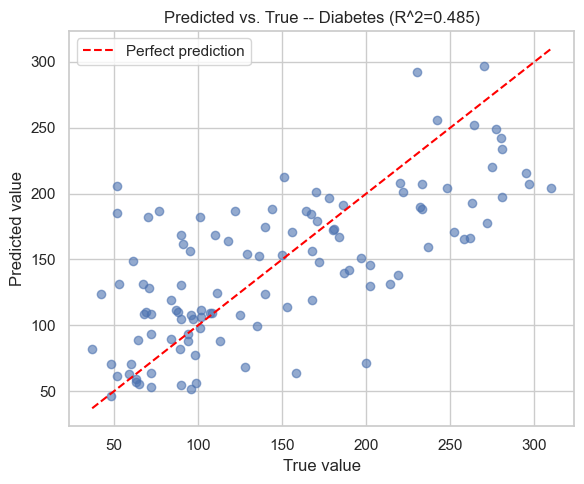

In [24]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(yr_test, yr_pred, alpha=0.6)
lims = [min(yr_test.min(), yr_pred.min()), max(yr_test.max(), yr_pred.max())]
ax.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
ax.set_xlabel("True value"); ax.set_ylabel("Predicted value")
ax.set_title(f"Predicted vs. True -- Diabetes (R^2={r2_manual:.3f})")
ax.legend()
plt.tight_layout()
plt.show()


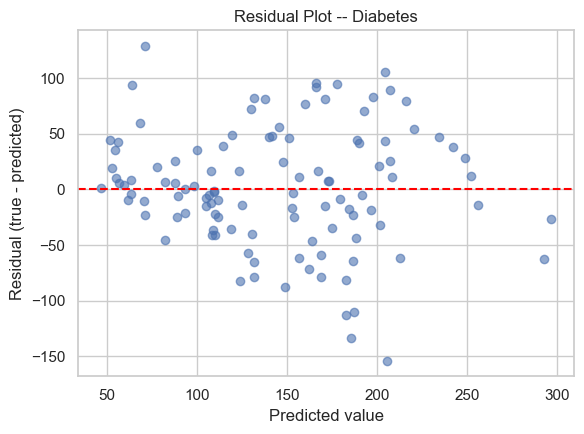

Residual mean: 1.865 (should be near 0 for an unbiased linear model)


In [25]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(yr_pred, residuals, alpha=0.6)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Predicted value"); ax.set_ylabel("Residual (true - predicted)")
ax.set_title("Residual Plot -- Diabetes")
plt.tight_layout()
plt.show()
print(f"Residual mean: {residuals.mean():.3f} (should be near 0 for an unbiased linear model)")


## 12. Custom Scorers & `cross_validate` With Multiple Metrics

Real projects often need a metric sklearn doesn't ship (e.g. a cost-weighted score). `make_scorer` wraps any function into something `cross_validate`/`GridSearchCV` can use directly.


In [26]:
def cost_weighted_score(y_true, y_pred, fn_cost=5, fp_cost=1):
    tp_, fp_, fn_, tn_ = manual_confusion_matrix(y_true, y_pred)
    total_cost = fn_ * fn_cost + fp_ * fp_cost
    return -total_cost  # sklearn scorers are "higher is better"

custom_scorer = make_scorer(cost_weighted_score)

results = cross_validate(
    LogisticRegression(max_iter=5000), Xc, yc, cv=5,
    scoring={"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc", "cost_weighted": custom_scorer}
)

for metric in ["accuracy", "f1", "roc_auc", "cost_weighted"]:
    scores = results[f"test_{metric}"]
    print(f"{metric:<15}: {scores.mean():.4f} +/- {scores.std():.4f}")
print("\n-> cost_weighted assumes missing a cancer case (FN) is 5x worse than a false alarm (FP) -- a business-specific metric no built-in scorer captures.")


accuracy       : 0.9508 +/- 0.0180
f1             : 0.9612 +/- 0.0140
roc_auc        : 0.9925 +/- 0.0068
cost_weighted  : -14.4000 +/- 7.2277

-> cost_weighted assumes missing a cancer case (FN) is 5x worse than a false alarm (FP) -- a business-specific metric no built-in scorer captures.


## 13. Threshold Tuning for a Business Constraint

Suppose the requirement is "catch at least 95% of positive cases" (high recall, e.g. cancer screening). Find the highest-precision threshold that still satisfies that recall floor.


In [27]:
recall_floor = 0.95
valid_thresholds = [(t, p, r) for t, p, r in zip(thresholds_sweep, prec_sweep, rec_sweep) if r >= recall_floor]

if valid_thresholds:
    best_t, best_p, best_r = max(valid_thresholds, key=lambda x: x[1])
    print(f"Highest-precision threshold meeting recall>={recall_floor}: t={best_t:.3f}, precision={best_p:.3f}, recall={best_r:.3f}")
    print(f"Compare to default threshold 0.5: precision={prec_manual:.3f}, recall={rec_manual:.3f}")
else:
    print(f"No threshold in the sweep achieves recall >= {recall_floor}")


Highest-precision threshold meeting recall>=0.95: t=0.730, precision=0.989, recall=0.956
Compare to default threshold 0.5: precision=0.947, recall=0.989


## 14. Calibration — Do Predicted Probabilities Mean What They Say?

A model can have perfect accuracy-ranking (high AUC) while its predicted probabilities are poorly calibrated (e.g. always overconfident). A reliability diagram checks whether "p=0.7" predictions are actually right about 70% of the time.


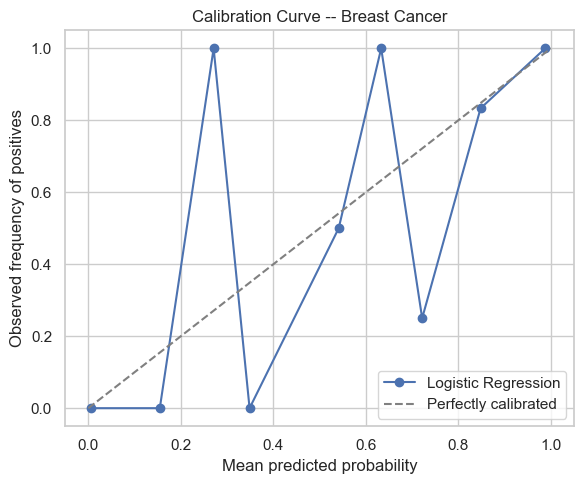

In [28]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(yc_test, yc_proba, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(prob_pred, prob_true, marker="o", label="Logistic Regression")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed frequency of positives")
ax.set_title("Calibration Curve -- Breast Cancer")
ax.legend()
plt.tight_layout()
plt.show()


In [29]:
calib_gap = np.abs(prob_true - prob_pred).mean()
points_per_bin = len(yc_test) / 10
print(f"Mean |observed - predicted| across bins: {calib_gap:.4f}")
print(f"Test set has only {len(yc_test)} points across 10 bins (~{points_per_bin:.0f}/bin) -- each bin's 'observed frequency' is itself a noisy estimate.")
if calib_gap < 0.05:
    print("-> Gap is small: predicted probabilities look trustworthy on their own, not just useful for ranking.")
else:
    print(f"-> Gap ({calib_gap:.3f}) is larger than a well-calibrated model would ideally show, but with ~{points_per_bin:.0f} points/bin this is at least partly small-sample noise, not necessarily miscalibration -- a bigger test set (or fewer bins) would be needed to tell those apart with confidence.")


Mean |observed - predicted| across bins: 0.2382
Test set has only 143 points across 10 bins (~14/bin) -- each bin's 'observed frequency' is itself a noisy estimate.
-> Gap (0.238) is larger than a well-calibrated model would ideally show, but with ~14 points/bin this is at least partly small-sample noise, not necessarily miscalibration -- a bigger test set (or fewer bins) would be needed to tell those apart with confidence.


## 15. Model Comparison — One Metrics Table

Comparing three classifiers on the same breast-cancer split across every metric derived above, side by side.


In [30]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM (RBF, probability)": SVC(probability=True, random_state=42),
}

rows = []
for name, model in models.items():
    model.fit(Xc_train, yc_train)
    pred = model.predict(Xc_test)
    proba = model.predict_proba(Xc_test)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(yc_test, pred),
        "Precision": precision_score(yc_test, pred),
        "Recall": recall_score(yc_test, pred),
        "F1": f1_score(yc_test, pred),
        "ROC-AUC": roc_auc_score(yc_test, proba),
        "LogLoss": log_loss(yc_test, proba),
        "MCC": matthews_corrcoef(yc_test, pred),
    })

comparison_df = pd.DataFrame(rows).set_index("Model").round(4)
comparison_df


,Accuracy,Precision,Recall,F1,ROC-AUC,LogLoss,MCC
Model,,,,,,,
Logistic Regression,0.9580,0.9468,0.9889,0.9674,0.9956,0.0872,0.9103
Random Forest,0.9580,0.9565,0.9778,0.9670,0.9949,0.1030,0.9098
"SVM (RBF, probability)",0.9231,0.9072,0.9778,0.9412,0.9736,0.1911,0.8354


In [31]:
best_per_metric = comparison_df.idxmax()
best_per_metric_loss = comparison_df["LogLoss"].idxmin()
print("Best model per metric:")
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "MCC"]:
    print(f"  {col:<10}: {best_per_metric[col]}")
print(f"  {'LogLoss':<10}: {best_per_metric_loss} (lowest is best)")
print("\n-> If different metrics disagree on the 'best' model, the right choice depends on which error type matters more for the actual use case -- there's no universal winner.")


Best model per metric:
  Accuracy  : Logistic Regression
  Precision : Random Forest
  Recall    : Logistic Regression
  F1        : Logistic Regression
  ROC-AUC   : Logistic Regression
  MCC       : Logistic Regression
  LogLoss   : Logistic Regression (lowest is best)

-> If different metrics disagree on the 'best' model, the right choice depends on which error type matters more for the actual use case -- there's no universal winner.


## 16. Summary

This notebook is intentionally metric-heavy rather than model-heavy: the same three classifiers and one regressor were evaluated under every angle this topic covers, so the emphasis stays on *what each number means* rather than on beating a previous accuracy score.

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
